# Surface renewal on one day of real data

Both `srflux` detectors run end to end on a single day from an almond orchard, using a
calibration fitted on other days.

| file | contents |
|---|---|
| `data/ola_2023-05-11_1hz.csv.gz` | 1 Hz **FWT** (fine-wire thermocouple, air) and **IRT** (radiometer, canopy skin), 86,400 samples |
| `data/ola_2023-05-11_flux30.csv` | 30-min **NETRAD**, **G**, **H**, **LE** from the eddy-covariance tower (48 blocks) |
| `data/ola_2023-05_calibration.json` | α and the flux-direction convention, fitted on 1–14 May 2023 **excluding this day** |

The two temperature series are the surface-renewal input; the four flux terms are the
reference and the energy balance. Nothing in the estimate is fitted on the day being scored.

Timestamps label the **start** of each period: a row stamped 12:00 covers 12:00–12:30, which
is what `pd.Grouper(freq="30min")` produces. If your reference fluxes are labelled by the end
of the period, shift them by one block before joining.

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from srflux import (HaarDetector, VanAttaDetector, prepare_block, ramp_flux, scores,
                    sensible_heat, sign_from_skewness, latent_heat_residual, daily_et)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

FS, BLOCK_S = 1.0, 1800.0
Z = {"FWT": 10.5, "IRT": 5.5}        # measurement height for air, canopy height for skin

hi = pd.read_csv("data/ola_2023-05-11_1hz.csv.gz", parse_dates=["TIMESTAMP"]).set_index("TIMESTAMP")
fx = pd.read_csv("data/ola_2023-05-11_flux30.csv", parse_dates=["TIMESTAMP"]).set_index("TIMESTAMP")
CAL = json.load(open("data/ola_2023-05_calibration.json"))

print(f"calibration fitted on {CAL['fit_period']}, excluding {CAL['excluded_day']}")
hi.describe().round(2)

calibration fitted on 2023-05-01 to 2023-05-14, excluding 2023-05-11


,FWT,IRT
count,86400.00,86400.00
mean,16.50,15.44
std,5.13,5.60
min,8.23,7.03
25%,11.28,10.06
50%,16.04,14.23
75%,21.59,21.58
max,24.83,23.62


## 1. The day

The fine wire measures air temperature at 10.5 m; the radiometer measures the canopy skin.
The energy balance closes to 1.03 and sensible heat is upward by day, downward at night.

energy-balance closure (H+LE)/(Rn-G) = 1.03


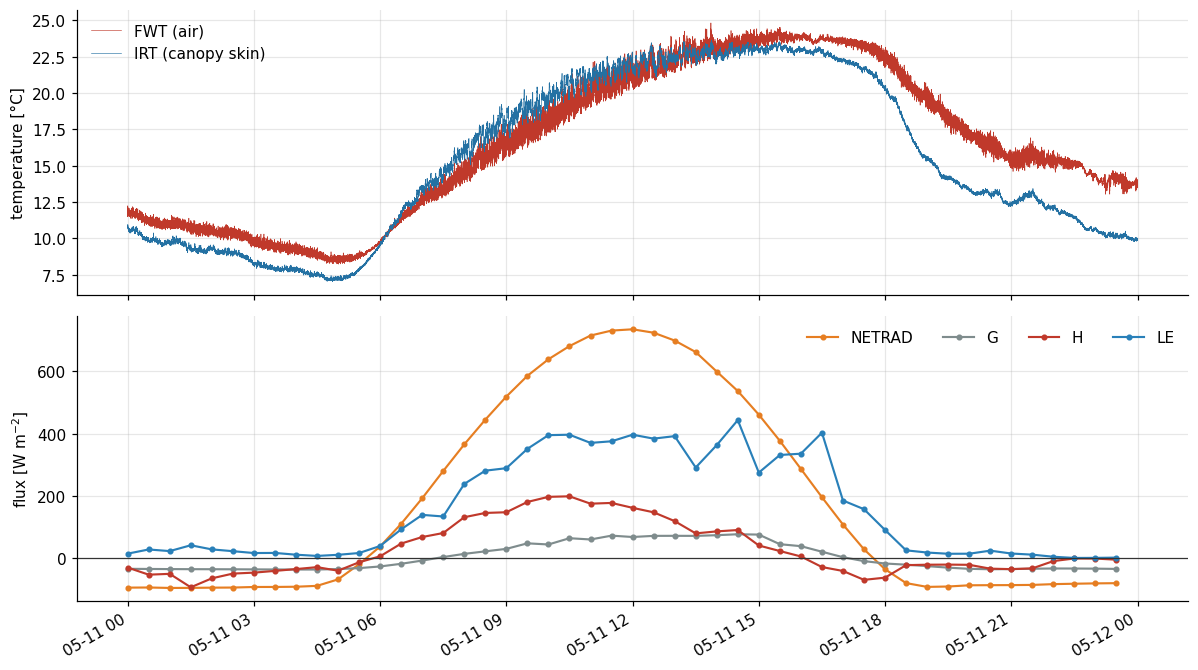

In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.2), sharex=True)

ax1.plot(hi.index, hi.FWT, lw=0.4, color="#c0392b", label="FWT (air)")
ax1.plot(hi.index, hi.IRT, lw=0.4, color="#2471a3", label="IRT (canopy skin)")
ax1.set_ylabel("temperature [°C]")
ax1.legend(loc="upper left", frameon=False)

for col, clr in [("NETRAD", "#e67e22"), ("G", "#7f8c8d"), ("H", "#c0392b"), ("LE", "#2980b9")]:
    ax2.plot(fx.index, fx[col], "-o", ms=3, lw=1.4, color=clr, label=col)
ax2.axhline(0, color="#333", lw=0.8)
ax2.set_ylabel("flux [W m$^{-2}$]")
ax2.legend(ncol=4, frameon=False)
fig.autofmt_xdate()
plt.tight_layout()

closure = (fx.H + fx.LE).sum() / (fx.NETRAD - fx.G).sum()
print(f"energy-balance closure (H+LE)/(Rn-G) = {closure:.2f}")

## 2. What a ramp looks like

One 30-min block at midday. The Haar detector high-passes the block (300 s moving mean),
convolves it with a step kernel, and takes local extrema of the coefficient above a
sigma-relative threshold as microfronts. The ramp amplitude is the median |coefficient| at
those fronts, in the scalar's own units.

Detection runs on the whole block; the plot shows the first few minutes so individual ramps
stay legible. The air ramps are several times larger than the skin ramps.

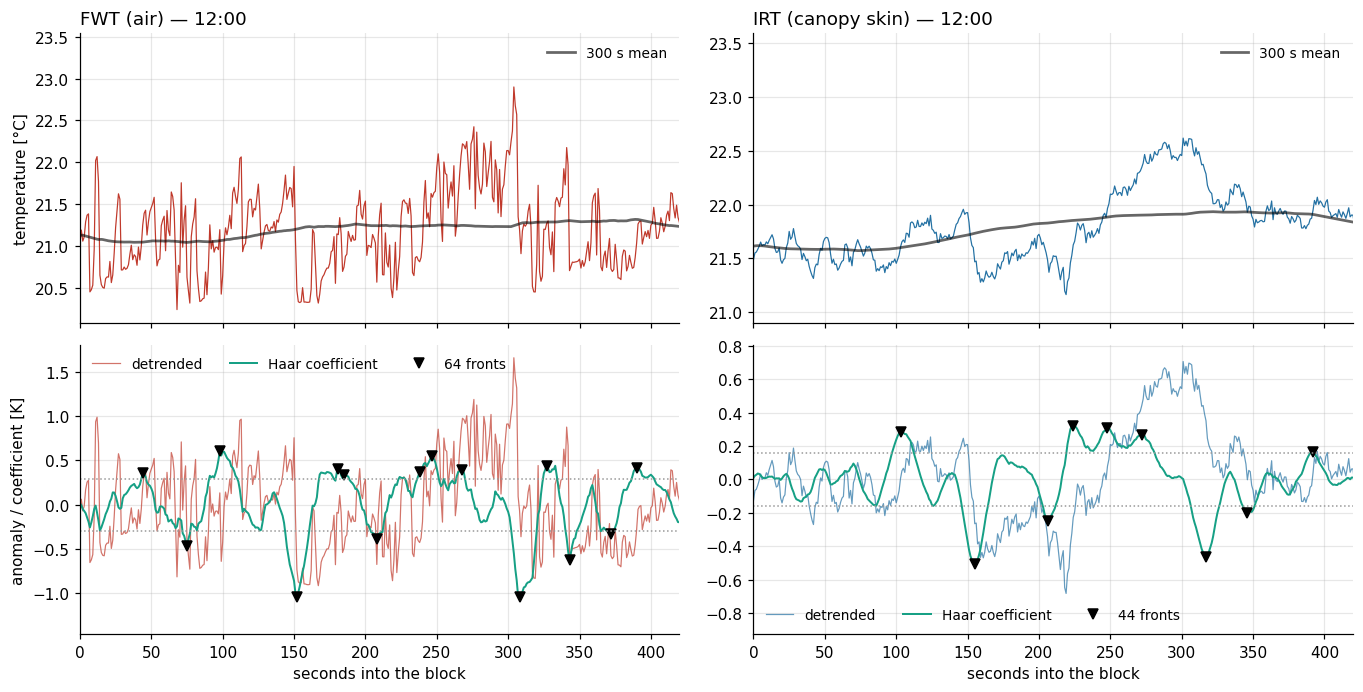

In [3]:
from srflux.preprocess import moving_average

t0, ZOOM_S = pd.Timestamp("2023-05-11 12:00:00"), 420
seg = hi.loc[t0:t0 + pd.Timedelta(seconds=BLOCK_S - 1)]
det = HaarDetector(fs=FS)

fig, axes = plt.subplots(2, 2, figsize=(12.5, 6.4), sharex=True)
for j, (col, clr, lab) in enumerate([("FWT", "#c0392b", "FWT (air)"),
                                     ("IRT", "#2471a3", "IRT (canopy skin)")]):
    v = prepare_block(seg[col].to_numpy(), fs=FS).values
    t = np.arange(len(v))
    coef, res = det.coefficients(v), det.detect(v)
    idx = res.extra["front_index"]

    axes[0, j].plot(t, v, lw=0.8, color=clr)
    axes[0, j].plot(t, moving_average(v, 300, FS), lw=1.8, color="k", alpha=0.6,
                    label="300 s mean")
    axes[0, j].set_title(f"{lab} — {t0:%H:%M}", loc="left")
    axes[0, j].legend(frameon=False, fontsize=9)

    axes[1, j].plot(t, v - moving_average(v, 300, FS), lw=0.8, color=clr, alpha=0.7,
                    label="detrended")
    axes[1, j].plot(t, coef, lw=1.3, color="#16a085", label="Haar coefficient")
    axes[1, j].plot(idx, coef[idx], "v", ms=6, color="k", label=f"{res.count} fronts")
    for s in (1, -1):
        axes[1, j].axhline(s * res.extra["threshold"], color="#999", ls=":", lw=1)
    axes[1, j].set_xlim(0, ZOOM_S)
    axes[1, j].set_xlabel("seconds into the block")
    axes[1, j].legend(frameon=False, fontsize=9, ncol=3)

axes[0, 0].set_ylabel("temperature [°C]")
axes[1, 0].set_ylabel("anomaly / coefficient [K]")
plt.tight_layout()

## 3. Ramp statistics for every block

`HaarDetector` (SR-WL) counts fronts and reports their median amplitude. `VanAttaDetector`
(SR-VA) solves the structure-function cubic; here it runs in `period_mode="unit"`, which
discards the fitted ramp period and uses the amplitude alone, with the lag read from the
calibration file.

Each is turned into an uncalibrated flux with the appropriate length scale — measurement
height for the air series, canopy height for the skin, since the volume renewed against a
canopy skin temperature is the canopy layer.

In [4]:
wl = HaarDetector(fs=FS)
va = VanAttaDetector(fs=FS, lag=CAL["va_lag_s"], period_mode=CAL["va_period_mode"])
SIGN = CAL["sign"]                       # per-channel skewness lag and threshold

rows = []
for t, g in hi.groupby(pd.Grouper(freq="30min")):
    row = {"TIMESTAMP": t}
    for col in ("FWT", "IRT"):
        qc = prepare_block(g[col].to_numpy(), fs=FS)
        if not qc.ok:
            continue
        rw, rv = wl.detect(qc.values), va.detect(qc.values)
        row[f"{col}_sign"] = sign_from_skewness(qc.values, fs=FS, tau=SIGN[col]["tau"],
                                                lag_s=SIGN[col]["lag_s"])
        if rw.valid:
            row[f"WL_{col}_N"], row[f"WL_{col}_A"] = rw.count, rw.amplitude
            row[f"WL_{col}_F"] = ramp_flux(rw.amplitude, count=rw.count, z=Z[col],
                                           block_s=BLOCK_S)
        if rv.valid:
            row[f"VA_{col}_A"] = rv.amplitude
            row[f"VA_{col}_F"] = ramp_flux(rv.amplitude, period=rv.period, z=Z[col])
    rows.append(row)

d = fx.join(pd.DataFrame(rows).set_index("TIMESTAMP"))
combos = [("WL", "FWT"), ("WL", "IRT"), ("VA", "FWT"), ("VA", "IRT")]

pd.DataFrame({"WL count": [d.WL_FWT_N.median(), d.WL_IRT_N.median()],
              "WL amplitude [K]": [d.WL_FWT_A.median(), d.WL_IRT_A.median()],
              "VA amplitude [K]": [d.VA_FWT_A.median(), d.VA_IRT_A.median()]},
             index=["FWT (air)", "IRT (skin)"]).round(3)

,WL count,WL amplitude [K],VA amplitude [K]
FWT (air),68.5,0.246,0.408
IRT (skin),56.5,0.099,0.225


## 4. Apply the calibration

```
H_SR = sign · α · ρ cp z · (ramp statistics)
```

Two things come from the calibration file and neither is fitted on this day:

* **α**, per regime. `unstable_day` (Rn > 50 W m⁻²) and `stable_night` (Rn < −20) are fitted
  separately, because a coefficient fitted on daytime convection over-estimates the weak
  nocturnal flux. At application time the regime is chosen from net radiation alone — never
  from H, which is the quantity being predicted.
* **the flux direction**, from the increment skewness of the same temperature channel, with
  the lag and flip threshold fitted per channel. Net radiation selects which coefficient
  applies; it does not decide which way the heat is going.

In [5]:
def regime_of(rn):
    if rn > 50:
        return "unstable_day"
    if rn < -20:
        return "stable_night"
    return "unstable_day" if rn > 0 else "stable_night"

d["regime"] = [regime_of(v) for v in d.NETRAD]

for meth, col in combos:
    key = f"{meth}_{col}"
    alpha = np.array([CAL["coefficients"][r][key]["alpha"] for r in d.regime])
    d[f"H_{key}"] = sensible_heat(d[f"{key}_F"], 1.0, sign=d[f"{col}_sign"]) * alpha

print("alpha by regime:")
print(pd.DataFrame({r: {k: v["alpha"] for k, v in c.items()}
                    for r, c in CAL["coefficients"].items()}).round(3).to_string())
print("\nflux direction (increment skewness):")
for ch, cfg in SIGN.items():
    print(f"  {ch}: lag {cfg['lag_s']:.0f} s, tau {cfg['tau']:+.3f}")

alpha by regime:
        unstable_day  stable_night
WL_FWT         0.651         0.465
WL_IRT         2.386         2.708
VA_FWT         0.012         0.008
VA_IRT         0.016         0.036

flux direction (increment skewness):
  FWT: lag 3 s, tau +0.261
  IRT: lag 3 s, tau -0.035


,method,scalar,r,nse,rmse,mbe,n
0,SR-WL,FWT,0.94,0.88,29.40,0.52,48
1,SR-WL,IRT,0.91,0.81,36.76,-2.04,48
2,SR-VA,FWT,0.95,0.90,26.91,1.11,48
3,SR-VA,IRT,0.83,0.53,57.66,-25.26,48


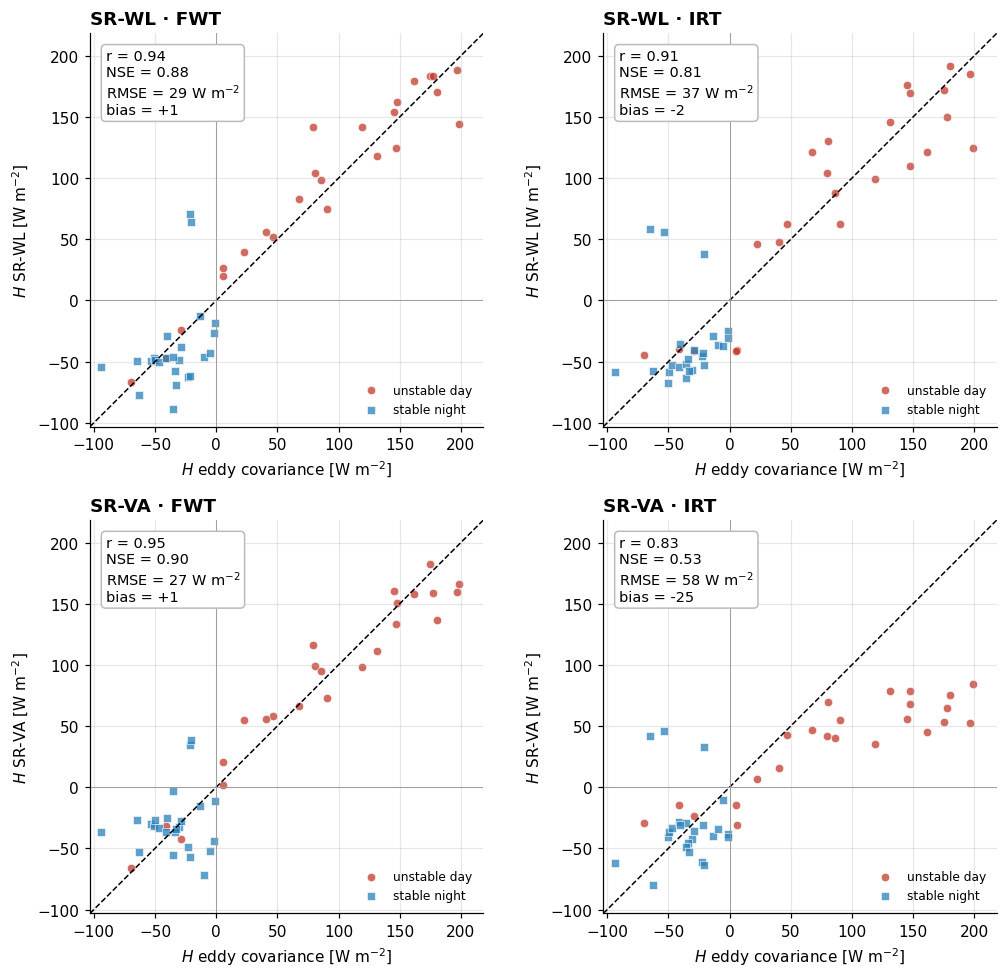

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(9.6, 9.0))
table = []
for ax, (meth, col) in zip(axes.ravel(), combos):
    v = d[[f"H_{meth}_{col}", "H", "regime"]].dropna()
    est, obs = v[f"H_{meth}_{col}"].to_numpy(), v.H.to_numpy()
    sc = scores(est, obs, 1.0)
    table.append({"method": f"SR-{meth}", "scalar": col, **{k: sc[k] for k in
                  ("r", "nse", "rmse", "mbe")}, "n": len(v)})
    for reg, mk, cl in [("unstable_day", "o", "#c0392b"), ("stable_night", "s", "#2980b9")]:
        m = v.regime == reg
        ax.scatter(obs[m], est[m], s=30, marker=mk, color=cl, alpha=0.75,
                   edgecolors="white", lw=0.5, label=reg.replace("_", " "))
    lim = [min(obs.min(), est.min()) * 1.1, max(obs.max(), est.max()) * 1.1]
    ax.plot(lim, lim, "k--", lw=1)
    ax.axhline(0, color="#999", lw=0.6)
    ax.axvline(0, color="#999", lw=0.6)
    ax.set(xlim=lim, ylim=lim, aspect="equal")
    ax.set_xlabel("$H$ eddy covariance [W m$^{-2}$]")
    ax.set_ylabel(f"$H$ SR-{meth} [W m$^{{-2}}$]")
    ax.set_title(f"SR-{meth} · {col}", loc="left", fontweight="bold")
    ax.text(0.04, 0.96, f"r = {sc['r']:.2f}\nNSE = {sc['nse']:.2f}\n"
                        f"RMSE = {sc['rmse']:.0f} W m$^{{-2}}$\nbias = {sc['mbe']:+.0f}",
            transform=ax.transAxes, va="top", fontsize=9.5,
            bbox=dict(boxstyle="round", fc="white", ec="#bbb"))
    ax.legend(fontsize=8, loc="lower right", frameon=False)
plt.tight_layout()

pd.DataFrame(table).round(2)

Read **NSE**, not r. Spanning day and night puts the points into two well-separated clouds,
and a correlation across both is flattered by that separation: an estimate with the right
sign but the wrong magnitude still scores a high r. NSE is zero for a prediction no better
than the mean of the observations and negative for one that is worse.

## 5. Energy balance and ET

Surface renewal enters evapotranspiration only through the H term of the residual, so an
error in α is diluted by however much of the available energy H represents:

```
LE = (Rn − G) − H_SR ,   ET = Σ LE·Δt / λ
```

The record is complete across all 48 blocks, so the sum runs over the full 24 hours.

,ET [mm]
SR-WL · FWT,5.31
SR-WL · IRT,5.40
SR-VA · FWT,5.29
SR-VA · IRT,6.22
EC residual (Rn−G−H),5.33
EC measured LE,5.52


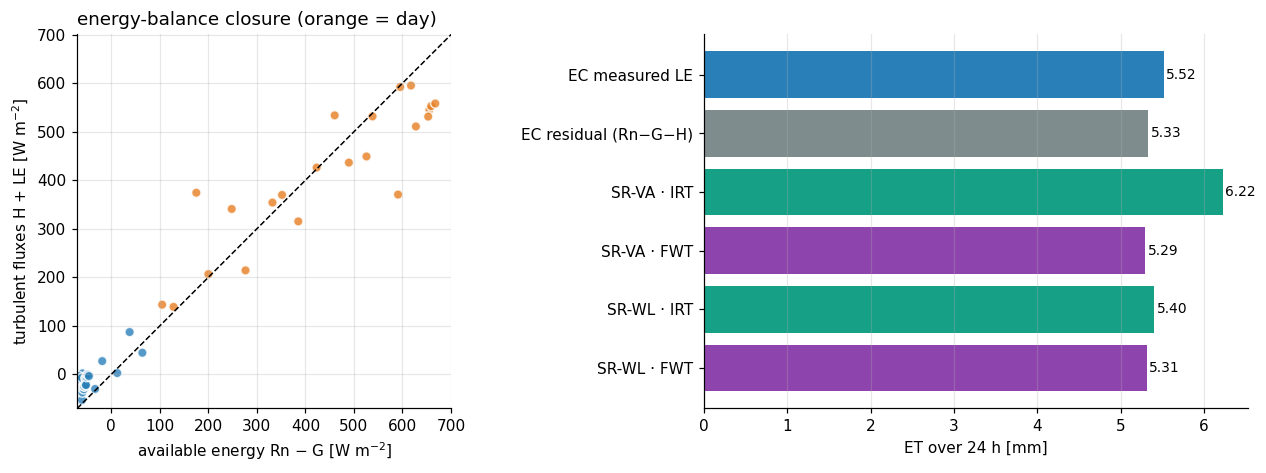

In [7]:
full = d.dropna(subset=["NETRAD", "G", "H", "LE"])
et = {f"SR-{m} · {c}": daily_et(latent_heat_residual(full.NETRAD, full.G, full[f"H_{m}_{c}"]),
                                block_s=BLOCK_S) for m, c in combos}
et["EC residual (Rn−G−H)"] = daily_et(
    latent_heat_residual(full.NETRAD.to_numpy(), full.G.to_numpy(), full.H.to_numpy()),
    block_s=BLOCK_S)
et["EC measured LE"] = daily_et(full.LE.to_numpy(), block_s=BLOCK_S)

fig, (axa, axb) = plt.subplots(1, 2, figsize=(12, 4.4))
avail, turb = (full.NETRAD - full.G).to_numpy(), (full.H + full.LE).to_numpy()
lim = [min(avail.min(), turb.min()) * 1.05, max(avail.max(), turb.max()) * 1.05]
axa.scatter(avail, turb, s=38, c=np.where(full.NETRAD > 50, "#e67e22", "#2980b9"),
            alpha=0.8, edgecolors="white")
axa.plot(lim, lim, "k--", lw=1)
axa.set(xlim=lim, ylim=lim, aspect="equal",
        xlabel="available energy Rn − G [W m$^{-2}$]",
        ylabel="turbulent fluxes H + LE [W m$^{-2}$]")
axa.set_title("energy-balance closure (orange = day)", loc="left")

names = list(et)
axb.barh(names, [et[k] for k in names],
         color=["#8e44ad", "#16a085", "#8e44ad", "#16a085", "#7f8c8d", "#2980b9"])
axb.set_xlabel("ET over 24 h [mm]")
for i, k in enumerate(names):
    axb.text(et[k] + 0.03, i, f"{et[k]:.2f}", va="center", fontsize=9)
axb.grid(axis="y", alpha=0)
plt.tight_layout()

pd.Series(et).round(2).to_frame("ET [mm]")

## Implementing this on your own data

1. **Prepare blocks** with `prepare_block` — range clip, gap fill, reject blocks that are
   too incomplete.
2. **Detect ramps** with `HaarDetector` (robust default) or `VanAttaDetector`. On a low-rate
   skin temperature use `period_mode="unit"` and choose the lag on a calibration window.
3. **Fit α per regime** against a reference flux, through the origin, on 10–21 days spread
   across conditions — not a single continuous campaign. Screen the calibration set per day
   first: one mis-scaled day carries enormous leverage in a through-origin fit.
4. **Fit the flux direction** with `fit_skewness_sign`, per channel, on the same window.
5. **Score with NSE**, and re-check α and the median ramp amplitude periodically — a drifting
   sensor moves α with no change in the flux.